# Lab 4, Day 1 — Regression on California Housing

Build an MLP regressor in PyTorch, then compare it head-to-head against your own Lab 2
NumPy gradient descent code on the exact same data. See `Lab4_Day1_Instructions.md`
for the full walkthrough.

This notebook is just a shell: it gives you a place to call and plot your functions,
but the loading, model, training loop, and comparison are yours to write.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Load and preprocess (`stage_a_regression.py`)

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.datasets import fetch_california_housing

torch.manual_seed(0)
np.random.seed(0)

housing = fetch_california_housing(as_frame=True)
housing.frame.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# TODO: load California Housing, split train/test, fit_transform the scaler on
# train only, transform test, reshape targets to (n, 1)
from stage_a_regression import load_data

X_train, y_train, X_test, y_test = load_data(housing, test_size=0.2)


In [5]:
print(y_train.shape)

torch.Size([16512, 1])


## Step 2-3: Model, loss, optimizer, training loop

In [6]:
# TODO: build_mlp from train.py (or write it directly), train with train_full_batch,
# store loss.item() each epoch - not the tensor itself
from train import build_mlp, train_full_batch

model = build_mlp(X_train)
mlp_losses = train_full_batch(X_train, y_train, model, lr=0.01)
print(mlp_losses)



[5.959393501281738, 5.540430068969727, 5.14880895614624, 4.7791595458984375, 4.4283905029296875, 4.09396505355835, 3.7737843990325928, 3.466130256652832, 3.1704623699188232, 2.8868188858032227, 2.6160476207733154, 2.3601858615875244, 2.1211540699005127, 1.9015852212905884, 1.704243779182434, 1.5322608947753906, 1.3877668380737305, 1.271397352218628, 1.1828467845916748, 1.1202200651168823, 1.0796518325805664, 1.0559768676757812, 1.043084979057312, 1.0347843170166016, 1.0258479118347168, 1.0124439001083374, 0.992779016494751, 0.966284990310669, 0.9342672824859619, 0.8989325761795044, 0.8627772927284241, 0.8281844258308411, 0.7971449494361877, 0.7709965109825134, 0.7503280639648438, 0.7350711226463318, 0.7245646119117737, 0.7177762389183044, 0.7135286331176758, 0.7105048894882202, 0.7075780630111694, 0.7038418650627136, 0.6985951066017151, 0.6915178298950195, 0.6825397610664368, 0.6718612909317017, 0.6598551869392395, 0.6470584273338318, 0.6340430974960327, 0.6213763952255249, 0.609574913

## Step 4: Evaluate and plot

In [7]:
# TODO: model.eval() + torch.no_grad() to get test MSE; plot the training loss curve
model.eval()
loss_fn = nn.MSELoss()

model.eval()
with torch.no_grad():
    test_preds = model(X_test)
    mlp_test_mse = loss_fn(test_preds, y_test).item()

print(f"Final test MSE: {mlp_test_mse:.4f}")

Final test MSE: 0.4269


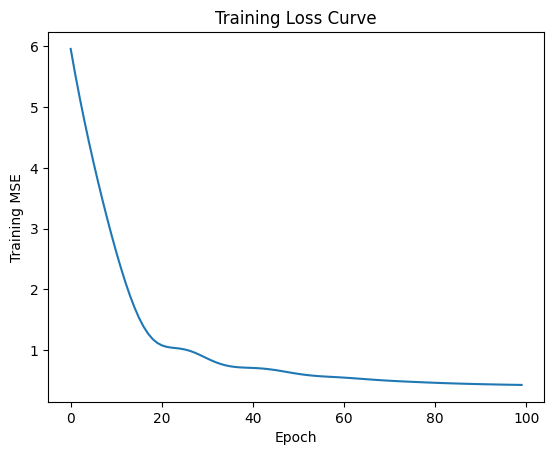

In [8]:
plt.plot(mlp_losses)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Training Loss Curve")
plt.show()

## Step 5: Compare against your Lab 2 NumPy code

MLP  test MSE: 0.4269
GD   test MSE: 0.5297


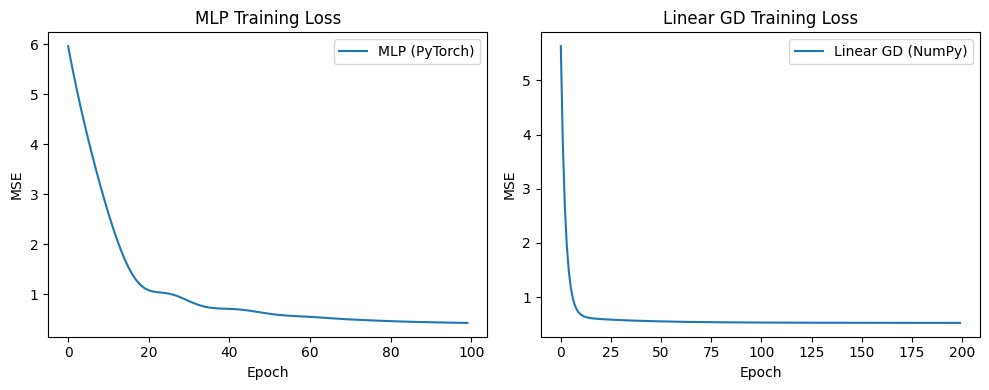

In [9]:
# TODO: fit a linear model on the same preprocessed data using your own hand-derived
# gradient descent, compare test MSE against the MLP, plot both curves side by side
from stage_a_regression import gradient_descent_numpy

w, b, gd_losses, gd_test_mse = gradient_descent_numpy(
    X_train,
    y_train,
    X_test,
    y_test
)

print(f"MLP  test MSE: {mlp_test_mse:.4f}")
print(f"GD   test MSE: {gd_test_mse:.4f}")

torch.save(model.state_dict(), "stage_a.pt")

# --- plot both curves ---
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(mlp_losses, label="MLP (PyTorch)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("MLP Training Loss")

plt.subplot(1, 2, 2)
plt.plot(gd_losses, label="Linear GD (NumPy)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Linear GD Training Loss")

plt.tight_layout()
plt.savefig("day1_curves.png", dpi=120)
plt.show()


### Written prompt

> **Your MLP barely beats the linear model, and might lose to it. What would have to be
> true about this data for the MLP to win decisively — and what does that tell you about
> when a neural network is the right tool?**

The MLP would only win big if the real relationship between the features and the price were non-linear, or depended on features interacting with each other in ways a straight line can't capture. It is wise to use a neural network when the pattern in the data is genuinely complex, and stick with a simple linear model when it already fits well.

---
**Before you close this notebook today:** save your trained model
(`torch.save(model.state_dict(), "stage_a.pt")`), and run the Fashion-MNIST loader
once (see `Lab4_Day2_Instructions.md` Step 1) so it's cached before Day 2. Keep this
notebook - Day 2 is a new notebook in the same folder.

In [10]:
torch.save(model.state_dict(), "stage_a.pt")